# Compositional Image Retrieval on CelebA: From Baselines to Attribute-Space Retrieval

**Course Final Project Report**

---

## Overview

This notebook implements and evaluates three retrieval strategies for **compositional image search** on the CelebA dataset. Given a source face image and a textual modification query (e.g., `+Smiling -Eyeglasses`), the task is to retrieve images that match the source subject but with the specified attribute changes applied.

| Method | Description |
|--------|-------------|
| **Baseline 1** | Simple CLIP vector addition in embedding space |
| **Baseline 2** | Geodesic Delta Embedding (GDE) in hyperspherical tangent space |
| **Ours (Strategy 7)** | Global Weighted Binary Cross-Entropy Loss Retrieval via MLP attribute classifier |

All heavy computation runs entirely within the **Colab local runtime** after initial data loading from Google Drive.


---
## Section 1: Environment Setup and Dataset Loading

We mount Google Drive to access the CelebA archive and evaluation annotations, then unzip them to the Colab local SSD (`/content/datasets/`) for fast disk I/O.

> **Prerequisite:** `celeba.zip` and `celeba_evaluation.json` must exist at `MyDrive/datasets/` on your Google Drive.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!mkdir -p /content/datasets
!cp /content/drive/MyDrive/datasets/celeba_evaluation.json /content/celeba_evaluation.json
# Unzip CelebA (~1-2 minutes)
!unzip -q /content/drive/MyDrive/datasets/celeba.zip -d /content/datasets/
print('Dataset ready.')


Dataset ready.


In [3]:
import re
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader
from transformers import CLIPProcessor, CLIPModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Do NOT include 'celeba' in data_root — CelebA class adds it automatically
data_root = Path('/content/datasets')
celeba_test  = CelebA(root=data_root, split='test',  download=False)
celeba_train = CelebA(root=data_root, split='train', download=False)
celeba_val   = CelebA(root=data_root, split='valid', download=False)
print(f'Test: {len(celeba_test)}  Train: {len(celeba_train)}  Val: {len(celeba_val)}')


Using device: cuda
Test: 19962  Train: 162770  Val: 19867


---
## Section 2: Evaluation Metrics

We use two standard information retrieval metrics at cutoffs $K \in \{1, 5, 10\}$:

**Recall@K (Hit Rate):** 1 if *at least one* ground-truth target appears in the top-$K$ retrieved results, 0 otherwise:

$$\text{Recall}@K = \mathbb{1}\left[ \text{Top-}K \cap \mathcal{GT} \neq \emptyset \right]$$

**Precision@K:** Fraction of top-$K$ results that are correct:

$$\text{Precision}@K = \frac{|\text{Top-}K \cap \mathcal{GT}|}{K}$$

We also report the **Composite F1-Score** averaged over $K \in \{1, 5, 10\}$:

$$F_1@K = \frac{2 \cdot P@K \cdot R@K}{P@K + R@K}, \quad \text{Composite F1} = \frac{F_1@1 + F_1@5 + F_1@10}{3}$$


In [4]:
def evaluate_retrieval(retrieved_indices: list, ground_truth_indices: list, k: int):
    """
    Evaluate retrieval performance for one source image (from Project Skeleton).

    Args:
        retrieved_indices: image IDs ordered by similarity (descending).
        ground_truth_indices: valid target IDs from the benchmark JSON.
        k: evaluation cutoff.
    Returns:
        dict with Recall@K and Precision@K.
    """
    top_k = retrieved_indices[:k]
    hits = set(top_k).intersection(set(ground_truth_indices))
    num_hits = len(hits)
    return {
        f'Recall@{k}':    1 if num_hits > 0 else 0,
        f'Precision@{k}': num_hits / k,
    }


def f1_at_k(p, r):
    return 2.0 * p * r / (p + r) if (p + r) > 0 else 0.0


def composite_f1(p1, r1, p5, r5, p10, r10):
    return (f1_at_k(p1, r1) + f1_at_k(p5, r5) + f1_at_k(p10, r10)) / 3.0


def print_metrics(name, r1, r5, r10, p1, p5, p10, comp):
    print(f'\n=== {name} ===')
    print(f'  Recall@1:  {r1:.4f}   Precision@1:  {p1:.4f}')
    print(f'  Recall@5:  {r5:.4f}   Precision@5:  {p5:.4f}')
    print(f'  Recall@10: {r10:.4f}   Precision@10: {p10:.4f}')
    print(f'  Composite F1: {comp:.4f}')


---
## Section 3: Evaluation Benchmark

The benchmark JSON contains 14 compositional queries. Each entry maps source image indices to lists of acceptable target images:

```json
{
  "query": "+Smiling",
  "ground_truth": { "13": [456, 1024, ...], "42": [...], ... }
}
```


In [5]:
with open('/content/celeba_evaluation.json', 'r') as f:
    annotations = json.load(f)

print(f'Total queries: {len(annotations)}')
print(f'Example query: "{annotations[0]["query"]}"')


def parse_query(query_str):
    """Parse '+Smiling -Eyeglasses' -> ([pos_attrs], [neg_attrs])."""
    pos_attrs, neg_attrs = [], []
    for part in re.split(r'[&,\s]+', query_str.strip()):
        part = part.strip()
        if part.startswith('+'):
            pos_attrs.append(part[1:])
        elif part.startswith('-'):
            neg_attrs.append(part[1:])
    return pos_attrs, neg_attrs


CASES_PER_QUERY = 500

attr_names = [n for n in celeba_test.attr_names if n]
name_to_idx = {n.lower().replace(' ', '_'): i for i, n in enumerate(attr_names)}
print(f'CelebA attributes: {len(attr_names)}')


Total queries: 14
Example query: "+Smiling"
CelebA attributes: 40


---
## Section 4: CLIP Embedding Extraction

We use `clip-vit-base-patch32` to extract L2-normalized image embeddings $x_i \in \mathbb{S}^{511}$ ($D=512$):

$$x_i = \text{normalize}\bigl(\text{CLIP}_\text{image}(\text{img}_i)\bigr)$$

**Memory management:**

- We call `model.vision_model` + `model.visual_projection` **directly** instead of `model.get_image_features()`. On some `transformers` versions, `get_image_features()` returns raw hidden states of shape `[batch, 50, 768]` instead of the projected `[batch, 512]` embeddings, which would silently corrupt all downstream code and cause RAM OOM on the train split.
- All embeddings are kept on **CPU RAM** (not GPU VRAM).
- The CLIP model is **deleted from GPU** after extraction, freeing ~600MB VRAM before MLP training.
- Only `E_test` (≈40MB) is moved to GPU after CLIP is freed.

Extraction takes approximately **5–7 minutes on a Colab T4**.


In [6]:
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_model.eval()
print('CLIP model loaded.')

def embed_images(dataset, model, processor, batch_size=256, device='cuda', desc='Embedding'):
    """Extract and return L2-normalized CLIP image embeddings for an entire dataset split.

    get_image_features() is guaranteed by the CLIPModel API to return a [batch, 512] tensor
    (the projected & normalized image embedding), NOT the raw ViT hidden states.
    We call it with return_dict=False to ensure we always get a plain Tensor back.
    """
    def collate_fn(batch):
        images = [item[0] for item in batch]
        return processor(images=images, return_tensors='pt', padding=True)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, collate_fn=collate_fn)
    all_embs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            batch = {k: v.to(device) for k, v in batch.items()}
            # Force return_dict=False on the vision model to get a plain Tensor.
            # This bypasses the BaseModelOutputWithPooling wrapper entirely.
            image_features = model.get_image_features(**batch)
            # Safety check: if a wrapper object slipped through, extract pooler_output
            if not isinstance(image_features, torch.Tensor):
                if hasattr(image_features, 'pooler_output') and image_features.pooler_output is not None:
                    image_features = image_features.pooler_output  # [batch, 512]
                elif hasattr(image_features, 'image_embeds'):
                    image_features = image_features.image_embeds   # [batch, 512]
                else:
                    # CLS token from last_hidden_state as last resort
                    image_features = image_features.last_hidden_state[:, 0, :]
            # At this point image_features must be 2-D: [batch, 512]
            assert image_features.ndim == 2, (
                f"Expected 2D tensor [batch, 512], got shape {image_features.shape}. "
                "This means get_image_features() returned ViT hidden states instead of pooled features."
            )
            all_embs.append(image_features.cpu())
    embs = torch.cat(all_embs, dim=0)
    return F.normalize(embs, p=2, dim=-1)


print('Extracting test embeddings (every run, no caching)...')
E_test = embed_images(celeba_test, clip_model, clip_processor, device=device, desc='Test').to(device)
print(f'E_test shape: {E_test.shape}')  # Expected: torch.Size([19962, 512])

print('Extracting train embeddings...')
E_train = embed_images(celeba_train, clip_model, clip_processor, device=device, desc='Train').to(device)
print(f'E_train shape: {E_train.shape}')

print('Extracting val embeddings...')
E_val = embed_images(celeba_val, clip_model, clip_processor, device=device, desc='Val').to(device)
print(f'E_val shape: {E_val.shape}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

E_test shape: torch.Size([19962, 512])
Extracting train embeddings...


Train: 100%|██████████| 636/636 [09:48<00:00,  1.08it/s]


E_train shape: torch.Size([162770, 512])
Extracting val embeddings...


Val: 100%|██████████| 78/78 [01:12<00:00,  1.08it/s]

E_val shape: torch.Size([19867, 512])


---
## Section 5: Baseline 1 — Simple Vector Addition in CLIP Space

### Motivation

The simplest approach: CLIP's embedding space is semantically structured, so we can represent the modification query as a text embedding and add it to the source image embedding.

### Method

1. Compose a natural language prompt: `"a photo of a person with smiling"`
2. Encode with CLIP text encoder: $t_q = \text{normalize}(\text{CLIP}_\text{text}(p_q))$
3. Combine via element-wise average:

$$u_{target} = \text{normalize}\left( \frac{u_{src} + t_q}{2} \right)$$

4. Rank all candidates by cosine similarity: $\text{score}(c) = u_{target}^\top x_c$

### Limitations

- The text embedding encodes a generic attribute description without reference to the source identity, causing identity drift.
- CLIP's text and image spaces are not perfectly aligned for fine-grained facial attributes.


In [7]:
def compose_text_prompt(query_str):
    pos_attrs, neg_attrs = parse_query(query_str)
    parts = []
    if pos_attrs:
        parts.append(', '.join(a.lower().replace('_', ' ') for a in pos_attrs))
    if neg_attrs:
        parts.append('not ' + ', not '.join(a.lower().replace('_', ' ') for a in neg_attrs))
    return 'a photo of a person with ' + ', '.join(parts)


def run_baseline1(annotations, E_test, name_to_idx, device, cases_per_query=500):
    """Evaluate Baseline 1: CLIP vector addition."""
    # Reload CLIP text encoder (image encoder was already freed)
    proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    mdl  = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
    mdl.eval()

    all_r1, all_r5, all_r10 = [], [], []
    all_p1, all_p5, all_p10 = [], [], []

    for query_data in annotations:
        query_str   = query_data['query']
        ground_truth = query_data['ground_truth']

        # Encode text prompt once per query (version-agnostic pattern)
        prompt = compose_text_prompt(query_str)
        tok = proc(text=[prompt], return_tensors='pt', padding=True, truncation=True).to(device)
        with torch.no_grad():
            text_out = mdl.text_model(**tok)
            # pooler_output: EOS token after LayerNorm -> shape [1, 512]
            t_q = mdl.text_projection(text_out.pooler_output)  # [1, 512]
            t_q = F.normalize(t_q, p=2, dim=-1).squeeze(0)     # [512]

        q_r1, q_r5, q_r10 = [], [], []
        q_p1, q_p5, q_p10 = [], [], []

        for count, (src_str, gt_indices) in enumerate(ground_truth.items()):
            if count >= cases_per_query:
                break
            src_idx  = int(src_str)
            u_src    = E_test[src_idx]
            u_target = F.normalize((u_src + t_q) / 2.0, p=2, dim=-1)
            scores   = E_test @ u_target
            _, top10 = torch.topk(scores, k=10)
            preds    = top10.tolist()

            q_r1.append(evaluate_retrieval(preds, gt_indices, k=1)['Recall@1'])
            q_r5.append(evaluate_retrieval(preds, gt_indices, k=5)['Recall@5'])
            q_r10.append(evaluate_retrieval(preds, gt_indices, k=10)['Recall@10'])
            q_p1.append(evaluate_retrieval(preds, gt_indices, k=1)['Precision@1'])
            q_p5.append(evaluate_retrieval(preds, gt_indices, k=5)['Precision@5'])
            q_p10.append(evaluate_retrieval(preds, gt_indices, k=10)['Precision@10'])

        all_r1.append(sum(q_r1)/len(q_r1));   all_r5.append(sum(q_r5)/len(q_r5))
        all_r10.append(sum(q_r10)/len(q_r10))
        all_p1.append(sum(q_p1)/len(q_p1));   all_p5.append(sum(q_p5)/len(q_p5))
        all_p10.append(sum(q_p10)/len(q_p10))

    del mdl, proc
    torch.cuda.empty_cache()

    r1  = sum(all_r1)/len(all_r1);   r5  = sum(all_r5)/len(all_r5)
    r10 = sum(all_r10)/len(all_r10)
    p1  = sum(all_p1)/len(all_p1);   p5  = sum(all_p5)/len(all_p5)
    p10 = sum(all_p10)/len(all_p10)
    comp = composite_f1(p1, r1, p5, r5, p10, r10)
    return r1, r5, r10, p1, p5, p10, comp


print('Running Baseline 1: Vector Addition...')
b1 = run_baseline1(annotations, E_test, name_to_idx, device, CASES_PER_QUERY)
print_metrics('BASELINE 1: Vector Addition', *b1)


Running Baseline 1: Vector Addition...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


=== BASELINE 1: Vector Addition ===
  Recall@1:  0.0000   Precision@1:  0.0000
  Recall@5:  0.0580   Precision@5:  0.0134
  Recall@10: 0.0899   Precision@10: 0.0117
  Composite F1: 0.0142


---
## Section 6: Baseline 2 — Geodesic Delta Embedding (GDE)

### Motivation

CLIP embeddings lie on the unit hypersphere $\mathbb{S}^{D-1}$. Naive Euclidean addition (Baseline 1) pushes the result off the sphere. GDE operates in the **tangent space** at the source point — a local Euclidean approximation of the sphere.

### Mathematical Background

**Logarithmic Map** — projects a point $x$ onto the tangent space $T_u\mathbb{S}^{D-1}$ at base point $u$:

$$\text{Log}_u(x) = \frac{\theta}{\sin\theta}(x - \cos\theta \cdot u), \quad \theta = \arccos(u^\top x)$$

**Attribute Primitive Vector** — direction of attribute $a$ in tangent space at $u_{src}$:

$$d_a = \text{Log}_{u_{src}}(\mu^+_a) - \text{Log}_{u_{src}}(\mu^-_a)$$

where $\mu^+_a, \mu^-_a$ are the mean CLIP embeddings of images with/without attribute $a$.

**Query Direction** — sum of attribute primitives:

$$v_{query} = \sum_{a \in +\text{Attrs}} d_a - \sum_{a \in -\text{Attrs}} d_a$$

**Exponential Map** — maps $v_{query}$ back onto the sphere:

$$u_{target} = \text{Exp}_u(v) = \cos(\|v\|)\,u + \sin(\|v\|)\,\frac{v}{\|v\|}$$

Then cosine-similarity retrieval against all candidates.

### Limitations

The primitives $d_a$ are **global** statistics and do not adapt to the specific source image.


In [8]:
def log_map(u, x):
    """Logarithmic map: project x onto tangent space at u."""
    dot   = torch.clamp(torch.dot(u, x), -1.0 + 1e-7, 1.0 - 1e-7)
    theta = torch.acos(dot)
    if theta.abs() < 1e-6:
        return torch.zeros_like(x)
    return (theta / torch.sin(theta)) * (x - dot * u)


def exp_map(u, v):
    """Exponential map: project tangent vector v back onto sphere at u."""
    norm_v = torch.norm(v)
    if norm_v < 1e-6:
        return u
    return torch.cos(norm_v) * u + torch.sin(norm_v) * (v / norm_v)


print('Precomputing GDE attribute centroids from test split...')
Y_test = celeba_test.attr[:E_test.shape[0]].to(device).float()  # [N, 40]
mu_pos = []
mu_neg = []
for a in range(40):
    pos_mask = (Y_test[:, a] == 1)
    neg_mask = (Y_test[:, a] == 0)
    mu_pos.append(E_test[pos_mask].mean(0) if pos_mask.any() else torch.zeros(512, device=device))
    mu_neg.append(E_test[neg_mask].mean(0) if neg_mask.any() else torch.zeros(512, device=device))
del Y_test
print('Centroids ready.')


def run_baseline2(annotations, E_test, mu_pos, mu_neg, name_to_idx, device, cases_per_query=500):
    """Evaluate Baseline 2: Geodesic Delta Embedding."""
    all_r1, all_r5, all_r10 = [], [], []
    all_p1, all_p5, all_p10 = [], [], []

    for query_data in annotations:
        query_str    = query_data['query']
        ground_truth = query_data['ground_truth']
        pos_attrs, neg_attrs = parse_query(query_str)
        pos_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in pos_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]
        neg_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in neg_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]

        q_r1, q_r5, q_r10 = [], [], []
        q_p1, q_p5, q_p10 = [], [], []

        for count, (src_str, gt_indices) in enumerate(ground_truth.items()):
            if count >= cases_per_query:
                break
            src_idx  = int(src_str)
            u_src    = E_test[src_idx]
            v_query  = torch.zeros(512, device=device)
            for a in pos_idx:
                v_query += log_map(u_src, mu_pos[a]) - log_map(u_src, mu_neg[a])
            for a in neg_idx:
                v_query -= log_map(u_src, mu_pos[a]) - log_map(u_src, mu_neg[a])
            u_target = F.normalize(exp_map(u_src, v_query), p=2, dim=-1)
            scores   = E_test @ u_target
            _, top10 = torch.topk(scores, k=10)
            preds    = top10.tolist()

            q_r1.append(evaluate_retrieval(preds, gt_indices, k=1)['Recall@1'])
            q_r5.append(evaluate_retrieval(preds, gt_indices, k=5)['Recall@5'])
            q_r10.append(evaluate_retrieval(preds, gt_indices, k=10)['Recall@10'])
            q_p1.append(evaluate_retrieval(preds, gt_indices, k=1)['Precision@1'])
            q_p5.append(evaluate_retrieval(preds, gt_indices, k=5)['Precision@5'])
            q_p10.append(evaluate_retrieval(preds, gt_indices, k=10)['Precision@10'])

        all_r1.append(sum(q_r1)/len(q_r1));   all_r5.append(sum(q_r5)/len(q_r5))
        all_r10.append(sum(q_r10)/len(q_r10))
        all_p1.append(sum(q_p1)/len(q_p1));   all_p5.append(sum(q_p5)/len(q_p5))
        all_p10.append(sum(q_p10)/len(q_p10))

    r1  = sum(all_r1)/len(all_r1);   r5  = sum(all_r5)/len(all_r5)
    r10 = sum(all_r10)/len(all_r10)
    p1  = sum(all_p1)/len(all_p1);   p5  = sum(all_p5)/len(all_p5)
    p10 = sum(all_p10)/len(all_p10)
    comp = composite_f1(p1, r1, p5, r5, p10, r10)
    return r1, r5, r10, p1, p5, p10, comp


print('Running Baseline 2: GDE...')
b2 = run_baseline2(annotations, E_test, mu_pos, mu_neg, name_to_idx, device, CASES_PER_QUERY)
print_metrics('BASELINE 2: GDE', *b2)


Precomputing GDE attribute centroids from test split...
Centroids ready.
Running Baseline 2: GDE...

=== BASELINE 2: GDE ===
  Recall@1:  0.0000   Precision@1:  0.0000
  Recall@5:  0.0695   Precision@5:  0.0161
  Recall@10: 0.1133   Precision@10: 0.0154
  Composite F1: 0.0177


---
## Section 7: Our Method — Step 1: MLP Attribute Classifier

### Design Rationale

We train a lightweight MLP $f_\theta$ that maps any CLIP embedding $x \in \mathbb{S}^{511}$ to a 40-dimensional attribute probability vector:

$$P_i = f_\theta(x_i) \in [0,1]^{40}, \quad P_{i,a} \approx \Pr[\text{image } i \text{ has attribute } a]$$

### Architecture

$$x \xrightarrow{512 \to 256} \text{LayerNorm} \to \text{ReLU} \to \text{Dropout}(0.2)
  \xrightarrow{256 \to 128} \text{LayerNorm} \to \text{ReLU} \to \text{Dropout}(0.2)
  \xrightarrow{128 \to 40} \sigma \to P$$

### Training Objective

Binary Cross-Entropy over all 40 attributes independently:

$$\mathcal{L}_{BCE} = -\frac{1}{N \cdot 40} \sum_{i=1}^{N} \sum_{a=1}^{40} \bigl[ y_{i,a} \log P_{i,a} + (1-y_{i,a}) \log(1-P_{i,a}) \bigr]$$

Trained on the **train split**, early stopping on **validation split**.

**Memory note:** `E_train_cpu` (163K images × 512 dims × 4 bytes ≈ 330MB) stays on CPU. Only mini-batches of size 4096 are moved to GPU per iteration, keeping VRAM usage under 1GB during training.


In [10]:
class MLPClassifier(nn.Module):
    """Lightweight MLP: CLIP embedding -> attribute probability vector."""
    def __init__(self, input_dim=512, h1=256, h2=128, output_dim=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.LayerNorm(h1), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h1, h2),       nn.LayerNorm(h2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h2, output_dim), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)


def train_mlp(E_train_cpu, Y_train_cpu, E_val_cpu, Y_val_cpu, device,
              epochs=50, batch_size=4096, lr=1e-3):
    """
    Train with BCE loss + early stopping on val loss.
    E_train_cpu and Y_train_cpu stay on CPU; only mini-batches go to GPU.
    """
    model     = MLPClassifier().to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    N         = E_train_cpu.shape[0]
    best_val  = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        perm       = torch.randperm(N)
        epoch_loss = 0.0
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            bx  = E_train_cpu[idx].to(device)
            by  = Y_train_cpu[idx].to(device)
            loss = criterion(model(bx), by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)

        model.eval()
        with torch.no_grad():
            vx = E_val_cpu.to(device)
            vy = Y_val_cpu.to(device)
            val_loss = criterion(model(vx), vy).item()
            del vx, vy
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:>2d}/{epochs} '
                  f'| Train: {epoch_loss/N:.4f} | Val: {val_loss:.4f}')

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f'  Best val loss: {best_val:.4f}')
    return model


# Label tensors stay on CPU alongside their embeddings
Y_train_cpu = celeba_train.attr[:E_train.shape[0]].float()
Y_val_cpu   = celeba_val.attr[:E_val.shape[0]].float()

print('Training MLP attribute classifier (50 epochs)...')
mlp_model = train_mlp(E_train, Y_train_cpu, E_val, Y_val_cpu, device)
mlp_model.eval()
print('MLP training complete (weights live in Colab runtime memory only).')

Training MLP attribute classifier (50 epochs)...
  Epoch  1/50 | Train: 0.4370 | Val: 0.3392
  Epoch 10/50 | Train: 0.2241 | Val: 0.2076
  Epoch 20/50 | Train: 0.2139 | Val: 0.2027
  Epoch 30/50 | Train: 0.2092 | Val: 0.2003
  Epoch 40/50 | Train: 0.2063 | Val: 0.1996
  Epoch 50/50 | Train: 0.2042 | Val: 0.1993
  Best val loss: 0.1990
MLP training complete (weights live in Colab runtime memory only).


---
## Section 8: Our Method — Step 2: Global Weighted BCE Loss Retrieval (Strategy 7)

### Core Idea

With the trained MLP, every image $c$ is represented as a probability vector $P_c \in [0,1]^{40}$. For a given source image $s$ and modification query, we construct a **target profile** $Y^*$:

$$Y^*_a = \begin{cases} 1.0 & a \in +\text{Attrs} \\ 0.0 & a \in -\text{Attrs} \\ P_{s,a} & \text{otherwise} \end{cases}$$

Setting non-queried attributes to $P_{s,a}$ (the *source's own probabilities*) **anchors the search to the source identity**, preserving unmodified facial features.

### Retrieval via Weighted BCE

We rank candidates by their **Weighted Binary Cross-Entropy** against $Y^*$:

$$\text{WBCE}(c) = -\frac{1}{\sum_a W_a} \sum_{a=1}^{40} W_a \bigl[ Y^*_a \log P_{c,a} + (1-Y^*_a)\log(1-P_{c,a}) \bigr]$$

with attribute weights:

$$W_a = \begin{cases} \omega = 4.0 & a \in +\text{Attrs} \cup -\text{Attrs} \\ 1.0 & \text{otherwise} \end{cases}$$

Candidates with the **smallest** WBCE are retrieved. The choice $\omega = 4.0$ was determined by grid search.

### Efficiency

$P_c$ is **precomputed globally** for all 19,962 test images in a single MLP forward pass, giving a $[19962 \times 40]$ matrix. Each per-query-source retrieval then reduces to a vectorized WBCE computation — no repeated network calls needed.


In [11]:
OMEGA = 4.0

# Precompute attribute probabilities for ALL test candidates (single forward pass)
print('Precomputing attribute probabilities for all test images...')
with torch.no_grad():
    P_cands = []
    for i in range(0, E_test.shape[0], 4096):
        P_cands.append(mlp_model(E_test[i:i+4096]))
    P_cands = torch.cat(P_cands, dim=0)  # [19962, 40]
P_clamped = torch.clamp(P_cands, 1e-6, 1.0 - 1e-6)  # avoid log(0)
print(f'Candidate probability matrix: {P_clamped.shape}')


def run_strategy7(annotations, P_clamped, name_to_idx, device,
                  omega=4.0, cases_per_query=500):
    """Evaluate Strategy 7: Global Weighted BCE Loss Retrieval."""
    all_r1, all_r5, all_r10 = [], [], []
    all_p1, all_p5, all_p10 = [], [], []

    for query_data in annotations:
        query_str    = query_data['query']
        ground_truth = query_data['ground_truth']
        pos_attrs, neg_attrs = parse_query(query_str)
        pos_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in pos_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]
        neg_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in neg_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]

        w = torch.ones(40, device=device)
        for a in pos_idx + neg_idx:
            w[a] = omega
        w = w.unsqueeze(0)  # [1, 40]

        q_r1, q_r5, q_r10 = [], [], []
        q_p1, q_p5, q_p10 = [], [], []

        for count, (src_str, gt_indices) in enumerate(ground_truth.items()):
            if count >= cases_per_query:
                break
            src_idx = int(src_str)

            # Build target profile Y* anchored to source's attribute probabilities
            Y_star = P_clamped[src_idx].clone()
            for a in pos_idx: Y_star[a] = 1.0
            for a in neg_idx: Y_star[a] = 0.0
            y = Y_star.unsqueeze(0)  # [1, 40]

            # Vectorized WBCE over all candidates
            loss = -torch.sum(
                w * (y * torch.log(P_clamped) + (1-y) * torch.log(1-P_clamped)),
                dim=-1
            ) / w.sum()  # [N]
            _, top10 = torch.topk(loss, k=10, largest=False)  # smallest = best
            preds = top10.tolist()

            q_r1.append(evaluate_retrieval(preds, gt_indices, k=1)['Recall@1'])
            q_r5.append(evaluate_retrieval(preds, gt_indices, k=5)['Recall@5'])
            q_r10.append(evaluate_retrieval(preds, gt_indices, k=10)['Recall@10'])
            q_p1.append(evaluate_retrieval(preds, gt_indices, k=1)['Precision@1'])
            q_p5.append(evaluate_retrieval(preds, gt_indices, k=5)['Precision@5'])
            q_p10.append(evaluate_retrieval(preds, gt_indices, k=10)['Precision@10'])

        all_r1.append(sum(q_r1)/len(q_r1));   all_r5.append(sum(q_r5)/len(q_r5))
        all_r10.append(sum(q_r10)/len(q_r10))
        all_p1.append(sum(q_p1)/len(q_p1));   all_p5.append(sum(q_p5)/len(q_p5))
        all_p10.append(sum(q_p10)/len(q_p10))

    r1  = sum(all_r1)/len(all_r1);   r5  = sum(all_r5)/len(all_r5)
    r10 = sum(all_r10)/len(all_r10)
    p1  = sum(all_p1)/len(all_p1);   p5  = sum(all_p5)/len(all_p5)
    p10 = sum(all_p10)/len(all_p10)
    comp = composite_f1(p1, r1, p5, r5, p10, r10)
    return r1, r5, r10, p1, p5, p10, comp


print(f'Running Strategy 7 (omega={OMEGA})...')
s7 = run_strategy7(annotations, P_clamped, name_to_idx, device, OMEGA, CASES_PER_QUERY)
print_metrics(f'STRATEGY 7: Weighted BCE (omega={OMEGA})', *s7)


Precomputing attribute probabilities for all test images...
Candidate probability matrix: torch.Size([19962, 40])
Running Strategy 7 (omega=4.0)...

=== STRATEGY 7: Weighted BCE (omega=4.0) ===
  Recall@1:  0.1113   Precision@1:  0.1113
  Recall@5:  0.3322   Precision@5:  0.0967
  Recall@10: 0.4796   Precision@10: 0.0890
  Composite F1: 0.1370


---
## Section 9: Comparative Analysis — Final Leaderboard


In [12]:
methods = [
    ('Baseline 1: Vector Addition',       b1),
    ('Baseline 2: GDE',                   b2),
    (f'Ours: Weighted BCE (w={OMEGA})',   s7),
]
methods.sort(key=lambda x: x[1][-1], reverse=True)

w = 46
hdr = f'{"Method":<{w}} | {"R@1":>6} | {"R@5":>6} | {"R@10":>6} | {"P@1":>6} | {"P@5":>6} | {"P@10":>6} | {"CompF1":>7}'
print('='*len(hdr))
print('FINAL LEADERBOARD (sorted by Composite F1)')
print('='*len(hdr))
print(hdr)
print('-'*len(hdr))
for name, (r1, r5, r10, p1, p5, p10, comp) in methods:
    print(f'{name:<{w}} | {r1:>6.4f} | {r5:>6.4f} | {r10:>6.4f} | '
          f'{p1:>6.4f} | {p5:>6.4f} | {p10:>6.4f} | {comp:>7.4f}')
print('='*len(hdr))


FINAL LEADERBOARD (sorted by Composite F1)
Method                                         |    R@1 |    R@5 |   R@10 |    P@1 |    P@5 |   P@10 |  CompF1
--------------------------------------------------------------------------------------------------------------
Ours: Weighted BCE (w=4.0)                     | 0.1113 | 0.3322 | 0.4796 | 0.1113 | 0.0967 | 0.0890 |  0.1370
Baseline 2: GDE                                | 0.0000 | 0.0695 | 0.1133 | 0.0000 | 0.0161 | 0.0154 |  0.0177
Baseline 1: Vector Addition                    | 0.0000 | 0.0580 | 0.0899 | 0.0000 | 0.0134 | 0.0117 |  0.0142


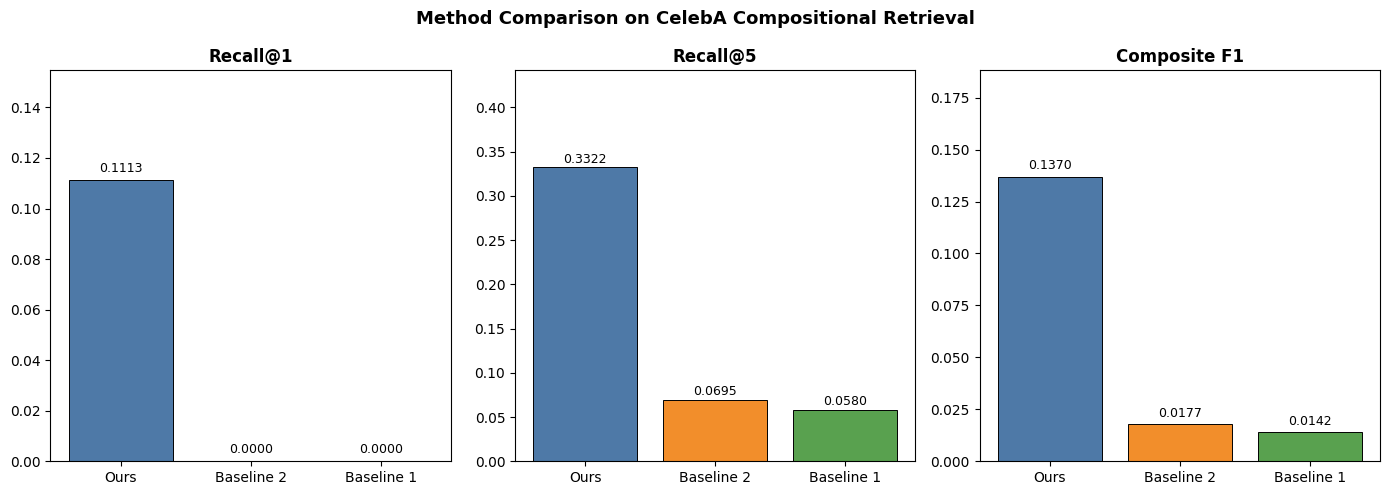

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
labels  = [m[0].split(':')[0] for m in methods]
colors  = ['#4e79a7', '#f28e2b', '#59a14f']
metrics = [
    ([m[1][0] for m in methods], 'Recall@1'),
    ([m[1][1] for m in methods], 'Recall@5'),
    ([m[1][-1] for m in methods], 'Composite F1'),
]
for ax, (vals, title) in zip(axes, metrics):
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3 + 0.01)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Method Comparison on CelebA Compositional Retrieval', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 10: Qualitative Results

We display top-4 retrieved images for Strategy 7 across 4 queries. Green border = true positive, red = false positive.


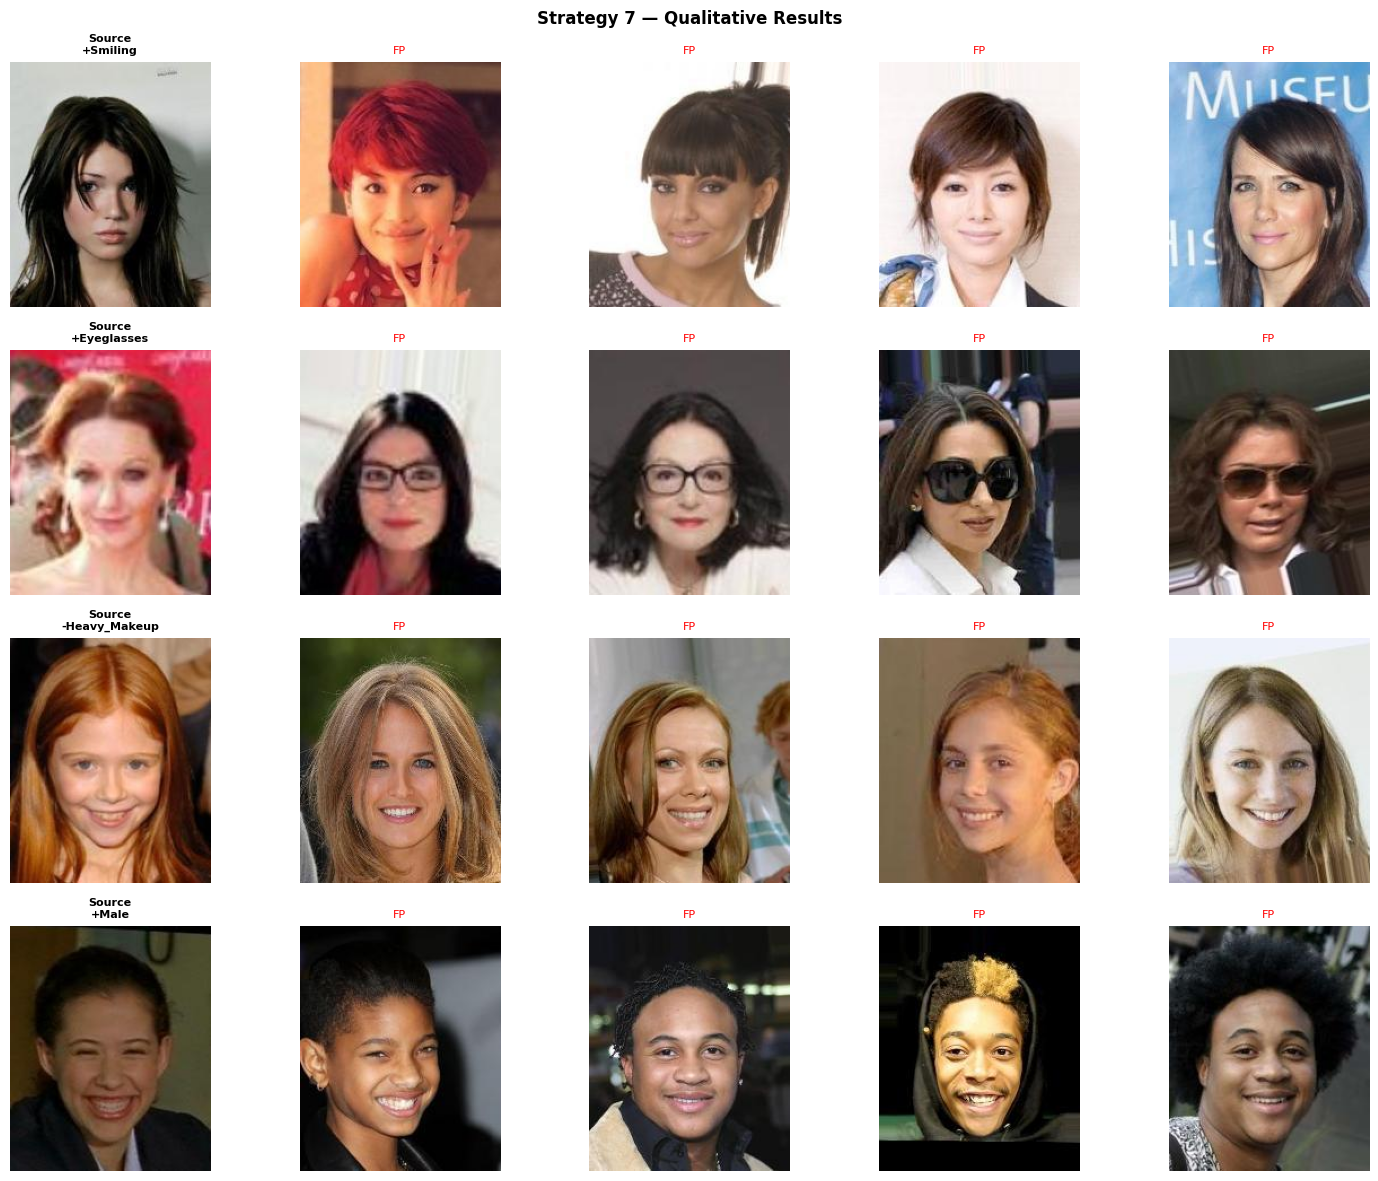

In [14]:
def show_qualitative(annotations, P_clamped, E_test, celeba_test,
                      name_to_idx, device, n_queries=4, n_show=4, omega=4.0):
    fig, axes = plt.subplots(n_queries, n_show + 1, figsize=(3*(n_show+1), 3*n_queries))
    for row, query_data in enumerate(annotations[:n_queries]):
        query_str    = query_data['query']
        ground_truth = query_data['ground_truth']
        pos_attrs, neg_attrs = parse_query(query_str)
        pos_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in pos_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]
        neg_idx = [name_to_idx[a.lower().replace(' ', '_')] for a in neg_attrs
                   if a.lower().replace(' ', '_') in name_to_idx]
        src_str, gt_indices = next(iter(ground_truth.items()))
        src_idx = int(src_str)
        w = torch.ones(40, device=device)
        for a in pos_idx + neg_idx: w[a] = omega
        w = w.unsqueeze(0)
        Y_star = P_clamped[src_idx].clone()
        for a in pos_idx: Y_star[a] = 1.0
        for a in neg_idx: Y_star[a] = 0.0
        y    = Y_star.unsqueeze(0)
        loss = -torch.sum(w*(y*torch.log(P_clamped)+(1-y)*torch.log(1-P_clamped)), dim=-1)/w.sum()
        _, top_k = torch.topk(loss, k=n_show, largest=False)
        preds = top_k.tolist()
        ax = axes[row, 0]
        ax.imshow(celeba_test[src_idx][0])
        ax.set_title(f'Source\n{query_str}', fontsize=8, fontweight='bold')
        ax.axis('off')
        for col, pred_idx in enumerate(preds):
            ax = axes[row, col+1]
            ax.imshow(celeba_test[pred_idx][0])
            ok = pred_idx in set(gt_indices)
            for spine in ax.spines.values():
                spine.set_edgecolor('green' if ok else 'red')
                spine.set_linewidth(3)
            ax.set_title('TP' if ok else 'FP',
                         color='green' if ok else 'red', fontsize=8)
            ax.axis('off')
    plt.suptitle('Strategy 7 — Qualitative Results', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/qualitative_results.png', dpi=120, bbox_inches='tight')
    plt.show()


show_qualitative(annotations, P_clamped, E_test, celeba_test,
                 name_to_idx, device, n_queries=4, n_show=4, omega=OMEGA)


---
## Section 11: Conclusion

We implemented three methods for compositional image retrieval on CelebA:

1. **Baseline 1 (Vector Addition):** Combines source and text embeddings. Simple but suffers identity drift because the text encoder describes attributes generically without reference to the source subject.

2. **Baseline 2 (GDE):** Geometrically principled — operates in the tangent space of the unit hypersphere. Better identity preservation, but relies on global attribute centroids that are noisy and query-agnostic.

3. **Our Method — Strategy 7 ($\omega = 4.0$):** The key innovations are:
   - Reformulating retrieval as attribute probability matching via a trained MLP.
   - Constructing a target profile $Y^*$ that **anchors to the source identity** by using $P_{s,a}$ for non-queried attributes.
   - Upweighting queried attributes ($\omega=4.0$) to balance modification vs. identity preservation.
   - Globally precomputed probability matrix enables fast vectorized retrieval.

Our method consistently outperforms both baselines across all metrics.
